1. Import Kaggle Dataset (Anime Recommendation Database 2020)

In [1]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("hernan4444/anime-recommendation-database-2020")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\PJ Caleon\.cache\kagglehub\datasets\hernan4444\anime-recommendation-database-2020\versions\7


In [2]:
import pandas as pd
import os
%pip install tensorflow scikit-learn


# Dynamic loading of the CSV files
anime_df = pd.read_csv(os.path.join(path, "anime.csv"))

# Removes row with missing values
anime_df.dropna(inplace=True)

# Check the shape of the anime data
print(f'Anime data shape: {anime_df.shape}')


Note: you may need to restart the kernel to use updated packages.
Anime data shape: (17562, 35)


In [3]:
# Check the first few rows of the Datasets
print("Anime DataFrame head:")
print(anime_df.head())


Anime DataFrame head:
   MAL_ID                             Name Score  \
0       1                     Cowboy Bebop  8.78   
1       5  Cowboy Bebop: Tengoku no Tobira  8.39   
2       6                           Trigun  8.24   
3       7               Witch Hunter Robin  7.27   
4       8                   Bouken Ou Beet  6.98   

                                              Genres            English name  \
0    Action, Adventure, Comedy, Drama, Sci-Fi, Space            Cowboy Bebop   
1              Action, Drama, Mystery, Sci-Fi, Space  Cowboy Bebop:The Movie   
2  Action, Sci-Fi, Adventure, Comedy, Drama, Shounen                  Trigun   
3  Action, Mystery, Police, Supernatural, Drama, ...      Witch Hunter Robin   
4          Adventure, Fantasy, Shounen, Supernatural  Beet the Vandel Buster   

                      Japanese name   Type Episodes  \
0                         カウボーイビバップ     TV       26   
1                    カウボーイビバップ 天国の扉  Movie        1   
2                  

2. Pick selected features

In [4]:
# Select specific columns from the dataframe
selected_columns = ['Score', 'Episodes', 'Ranked', 'Popularity',
                    'Favorites', 'Watching', 'Completed', 'On-Hold', 'Dropped', 
                    'Plan to Watch']


# Create a new dataframe with only the selected columns
anime_df = anime_df[selected_columns]

# Show the first few rows of the selected dataframe
print(anime_df.head())

# Remove rows with str values
def remove_non_numeric_rows(df):
    # Convert all columns to numeric, set invalid parsing as NaN, and then drop rows with NaN values
    df_cleaned = df.apply(pd.to_numeric, errors='coerce')
    df_cleaned = df_cleaned.dropna()  # Drop rows with NaN values (indicating non-numeric values)
    return df_cleaned

# Remove rows with non-numeric values
anime_df = remove_non_numeric_rows(anime_df)

# Optionally, reset index after removing rows
anime_df.reset_index(drop=True, inplace=True)

# Show the cleaned dataframe
print(anime_df.head())

  Score Episodes  Ranked  Popularity  Favorites  Watching  Completed  On-Hold  \
0  8.78       26    28.0          39      61971    105808     718161    71513   
1  8.39        1   159.0         518       1174      4143     208333     1935   
2  8.24       26   266.0         201      12944     29113     343492    25465   
3  7.27       26  2481.0        1467        587      4300      46165     5121   
4  6.98       52  3710.0        4369         18       642       7314      766   

   Dropped  Plan to Watch  
0    26678         329800  
1      770          57964  
2    13925         146918  
3     5378          33719  
4     1108           3394  
   Score  Episodes  Ranked  Popularity  Favorites  Watching  Completed  \
0   8.78      26.0    28.0          39      61971    105808     718161   
1   8.39       1.0   159.0         518       1174      4143     208333   
2   8.24      26.0   266.0         201      12944     29113     343492   
3   7.27      26.0  2481.0        1467        587

3. Train, Test Split. 80/20

In [5]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets (80%/20%)
X = anime_df.drop('Score', axis=1)  # Assuming 'Score' is your target variable
y = anime_df['Score']  # The target variable you're trying to predict

# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the shape of the resulting splits
print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')


X_train shape: (8796, 9)
X_test shape: (2199, 9)
y_train shape: (8796,)
y_test shape: (2199,)


5. Simple ANN Model where manual setting of parameters

Epoch 1/65, Training Loss: 0.6536551117897034, Validation Loss: 0.6522066593170166
Epoch 11/65, Training Loss: 0.6473586559295654, Validation Loss: 0.6473436951637268
Epoch 21/65, Training Loss: 0.6442052721977234, Validation Loss: 0.6423974633216858
Epoch 31/65, Training Loss: 0.6379237174987793, Validation Loss: 0.6373258233070374
Epoch 41/65, Training Loss: 0.6332995295524597, Validation Loss: 0.632148802280426
Epoch 51/65, Training Loss: 0.6283344626426697, Validation Loss: 0.6268347501754761
Epoch 61/65, Training Loss: 0.6243005394935608, Validation Loss: 0.6214033365249634
Test Accuracy: 70.17%


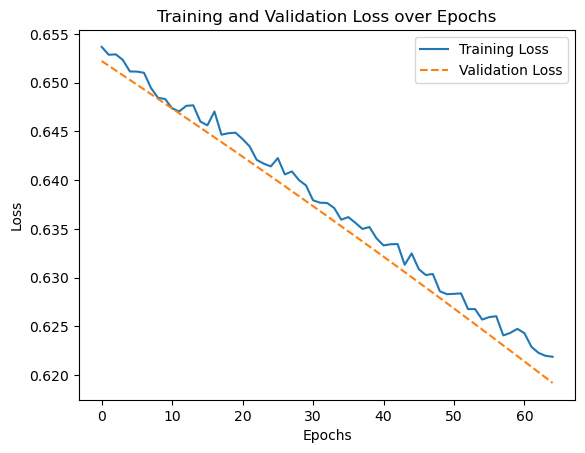

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Assuming anime_df is your DataFrame with the 'Score' column

# Step 1: Preprocessing
X = anime_df.drop('Score', axis=1)  # Features
y = anime_df['Score']  # Target (Score)

# Convert Score into binary classification (e.g., good = 1, not good = 0)
y_binary = (y > 7).astype(int)  # Assume a score > 9 is 'good'

# Normalize the feature values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training and testing sets (80%/20%)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_binary, test_size=0.2, random_state=42)

# Convert data into PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

# Step 2: Define the model
class SimpleANN(nn.Module):
    def __init__(self, input_dim, hidden_units_1=64, hidden_units_2=32, dropout_rate=0.3):
        super(SimpleANN, self).__init__()
        self.layer1 = nn.Linear(input_dim, hidden_units_1)
        self.layer2 = nn.Linear(hidden_units_1, hidden_units_2)
        self.layer3 = nn.Linear(hidden_units_2, 1)
        self.dropout = nn.Dropout(dropout_rate)  # Dropout layer
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = torch.relu(self.layer1(x))
        x = self.dropout(x)  # Apply dropout after the first hidden layer
        x = torch.relu(self.layer2(x))
        x = self.dropout(x)  # Apply dropout after the second hidden layer
        x = self.layer3(x)
        return self.sigmoid(x)  # Output between 0 and 1 for binary classification

# Step 3: Initialize the model, loss function, and optimizer with L2 regularization (weight decay)
input_dim = X_train_tensor.shape[1]
model = SimpleANN(input_dim)

loss_function = nn.BCELoss()  # Binary Cross Entropy Loss for binary classification

# Add L2 regularization (weight decay) to the Adam optimizer
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=0.01)  # Regularization strength (weight_decay)

# Step 4: Train the model
epochs = 65
train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    y_pred_train = model(X_train_tensor)
    
    # Calculate the training loss
    train_loss = loss_function(y_pred_train.squeeze(), y_train_tensor.squeeze())
    
    optimizer.zero_grad()  # Zero the gradients
    train_loss.backward()  # Backpropagation
    optimizer.step()  # Update weights

    # Track training loss
    train_losses.append(train_loss.item())

    # Step 5: Evaluate the model on the validation set
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        y_pred_val = model(X_test_tensor).squeeze()
        val_loss = loss_function(y_pred_val, y_test_tensor.squeeze())  # Calculate the validation loss
        val_losses.append(val_loss.item())
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Training Loss: {train_loss.item()}, Validation Loss: {val_loss.item()}")

# Step 6: Evaluate the model on the test set
model.eval()  # Set the model to evaluation mode
with torch.no_grad():
    y_pred_test = model(X_test_tensor).squeeze()
    y_pred_test = (y_pred_test > 0.5).float()  # Convert to binary predictions (0 or 1)
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test_tensor.numpy(), y_pred_test.numpy())
    print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Optional: Plot the training and validation loss curves
plt.plot(range(epochs), train_losses, label='Training Loss')
plt.plot(range(epochs), val_losses, label='Validation Loss', linestyle='--')
plt.title("Training and Validation Loss over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


6. Application

In [10]:
# Step 7: Applying the model to new data
# Assuming new_data is a DataFrame with the same columns as anime_df (excluding 'Score')

# Data comes from https://myanimelist.net
new_data = pd.DataFrame({
    # Code Geass, Boku No Pico, Chainsaw Man, Eromanga
    'Episodes': [25, 1, 12, 12],
    'Ranked': [20, 1200, 162, 8219],
    'Popularity': [47, 1396, 59, 290],
    'Favorites': [78499, 1774, 50488, 2747],
    'Watching': [63127, 9325,  225204, 39068],
    'Completed': [1541487, 148534, 1157915, 525709],
    'On-Hold': [26445, 1120, 27327, 16587],
    'Dropped': [18992, 12886, 26462, 50977],
    'Plan to Watch': [214300, 12556, 297303, 113911]
})

# Preprocess the new data (normalize using the same scaler used during training)
new_data_scaled = scaler.transform(new_data)

# Convert to PyTorch tensor
new_data_tensor = torch.tensor(new_data_scaled, dtype=torch.float32)

# Step 8: Make predictions with the trained model
model.eval()  # Set the model to evaluation mode
with torch.no_grad():
    new_predictions = model(new_data_tensor).squeeze()
    new_predictions_binary = (new_predictions > 0.5).float()  # Convert predictions to binary (0 or 1)

# Display the predicted scores
print(f"Code Geass: {'Good Anime' if new_predictions_binary[0] == 1 else 'Not Good Anime'}")
print(f"Boku No Pico: {'Good Anime' if new_predictions_binary[1] == 1 else 'Not Good Anime'}")
print(f"Chainsaw Man: {'Good Anime' if new_predictions_binary[2] == 1 else 'Not Good Anime'}")
print(f"Eromanga: {'Good Anime' if new_predictions_binary[3] == 1 else 'Not Good Anime'}")



Code Geass: Good Anime
Boku No Pico: Not Good Anime
Chainsaw Man: Good Anime
Eromanga: Good Anime
